In [7]:
!pip install seaborn textblob

You should consider upgrading via the 'C:\Users\admin\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [8]:
# Task 1: Dataset Generation
import pandas as pd

# Creating a custom dataset mimicking raw text scraped from e-commerce reviews
raw_scraped_data = {
    "Review_Title": [
        "Amazing product!",
        "Terrible quality",
        "Decent, does the job",
        "Absolutely loved it",
        "Waste of money",
        "It is okay I guess",
    ],
    "Review_Text": [
        "This completely changed how I work. Highly recommend to everyone!",
        "Broke within two days. Absolute garbage and customer service was rude.",
        "It is okay for the price, but nothing spectacular. Average speed.",
        "Super fast shipping and works flawlessly. Best purchase this year.",
        "Do not buy this. It does not work as advertised at all.",
        "The product arrived late and looks mediocre, but it works.",
    ],
    "Rating": [5, 1, 3, 5, 1, 3],
}

# Convert to DataFrame
df = pd.DataFrame(raw_scraped_data)

print("--- TASK 1 COMPLETE: Custom Dataset Created ---")
df

--- TASK 1 COMPLETE: Custom Dataset Created ---


,Review_Title,Review_Text,Rating
0,Amazing product!,This completely changed how I work. Highly rec...,5
1,Terrible quality,Broke within two days. Absolute garbage and cu...,1
2,"Decent, does the job","It is okay for the price, but nothing spectacu...",3
3,Absolutely loved it,Super fast shipping and works flawlessly. Best...,5
4,Waste of money,Do not buy this. It does not work as advertise...,1
5,It is okay I guess,"The product arrived late and looks mediocre, b...",3


task 2

In [9]:
# Task 2: Exploratory Data Analysis (EDA)

print("--- TASK 2: Exploring Data Structure & Integrity ---\n")

# 1. Check data types and structure
print("1. Dataset Structural Info:")
print(df.info())
print("\n" + "=" * 40 + "\n")

# 2. Check for missing values / data issues
print("2. Missing Values Check:")
print(df.isnull().sum())
print("\n" + "=" * 40 + "\n")

# 3. Inspect quantitative patterns
print("3. Rating Field Descriptive Statistics:")
print(df["Rating"].describe())

--- TASK 2: Exploring Data Structure & Integrity ---

1. Dataset Structural Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Review_Title  6 non-null      object
 1   Review_Text   6 non-null      object
 2   Rating        6 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 272.0+ bytes
None


2. Missing Values Check:
Review_Title    0
Review_Text     0
Rating          0
dtype: int64


3. Rating Field Descriptive Statistics:
count    6.000000
mean     3.000000
std      1.788854
min      1.000000
25%      1.500000
50%      3.000000
75%      4.500000
max      5.000000
Name: Rating, dtype: float64


task 3

--- TASK 3: Generating Visual Formats ---


KeyError: 'Sentiment'

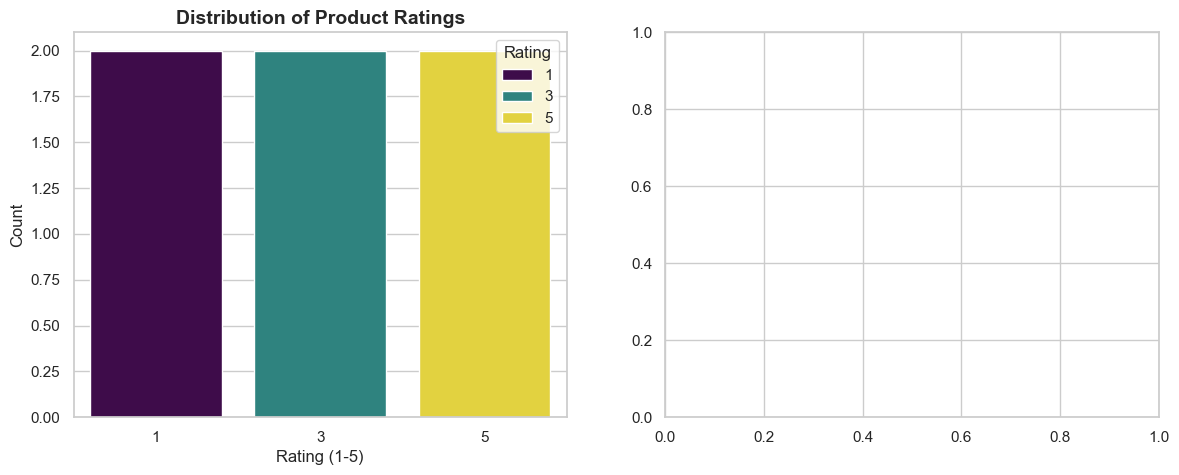

In [10]:
# Task 3: Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TASK 3: Generating Visual Formats ---")

# Set up matplotlib figure style and subplots (1 row, 2 columns)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of Ratings (Bar Chart)
sns.countplot(x="Rating", data=df, ax=axes[0], palette="viridis", hue="Rating")
axes[0].set_title("Distribution of Product Ratings", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Rating (1-5)")
axes[0].set_ylabel("Count")

# Plot 2: Public Opinion Breakdown (Pie Chart)
sentiment_counts = df["Sentiment"].value_counts()
axes[1].pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    colors=["#4CAF50", "#F44336", "#FFC107"],
    startangle=140,
    explode=[0.05 if i == 0 else 0 for i in range(len(sentiment_counts))],
)
axes[1].set_title(
    "Public Opinion Trends (Sentiment Analysis)", fontsize=14, fontweight="bold"
)

# Display charts clean and inline
plt.tight_layout()
plt.show()

print("--- TASK 3 COMPLETE: Visual Portfolio Dashboard Rendered ---")

task 4

In [11]:
# Task 4: Sentiment Analysis using NLP Lexicons
from textblob import TextBlob


# Function to analyze and classify text polarity
def analyze_sentiment(text):
    analysis = TextBlob(text)
    # Polarity ranges from -1 (negative) to 1 (positive)
    if analysis.sentiment.polarity > 0.1:
        return "Positive"
    elif analysis.sentiment.polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"


# Apply the NLP classification to our dataset
df["Sentiment"] = df["Review_Text"].apply(analyze_sentiment)

print("--- TASK 4 COMPLETE: Text Data Classified ---")
df[["Review_Text", "Sentiment"]]

--- TASK 4 COMPLETE: Text Data Classified ---


,Review_Text,Sentiment
0,This completely changed how I work. Highly rec...,Positive
1,Broke within two days. Absolute garbage and cu...,Neutral
2,"It is okay for the price, but nothing spectacu...",Positive
3,Super fast shipping and works flawlessly. Best...,Positive
4,Do not buy this. It does not work as advertise...,Neutral
5,"The product arrived late and looks mediocre, b...",Negative
